In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


# 0. Import

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns

import os
import matplotlib.pyplot as plt

import sklearn
from sklearn.svm import SVC
from sklearn.metrics import balanced_accuracy_score, roc_auc_score, accuracy_score, confusion_matrix, roc_curve
from scipy.stats import zscore, pearsonr, uniform
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold, StratifiedKFold, RandomizedSearchCV

from scipy.io import loadmat

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score
from sklearn.metrics import accuracy_score

# 1. Load data

In [ ]:
# categorical variable train dataframe
file_path_trainC = "/content/gdrive/MyDrive/Competitions/WISD_2025/global_challenge/data_widsdatathon2025/TRAIN_NEW/TRAIN_CATEGORICAL_METADATA_new.xlsx"
train_cat = pd.read_excel(file_path_trainC)

# Functional Connectome Matrices
file_path_trainFCM = "/content/gdrive/MyDrive/Competitions/WISD_2025/global_challenge/data_widsdatathon2025/TRAIN_NEW/TRAIN_FUNCTIONAL_CONNECTOME_MATRICES_new_36P_Pearson.csv"
train_FCM = pd.read_csv(file_path_trainFCM)

# Quantitative varaible train dataframe
file_path_trainQ = "/content/gdrive/MyDrive/Competitions/WISD_2025/global_challenge/data_widsdatathon2025/TRAIN_NEW/TRAIN_QUANTITATIVE_METADATA_new.xlsx"
train_Quant = pd.read_excel(file_path_trainQ)

# ADHD and Sex solutions dataframe for model training
file_path_trainS = "/content/gdrive/MyDrive/Competitions/WISD_2025/global_challenge/data_widsdatathon2025/TRAIN_NEW/TRAINING_SOLUTIONS.xlsx"
train_Solutions = pd.read_excel(file_path_trainS)

In [ ]:
# load in test categorical dataframe
file_path_testC = "/content/gdrive/MyDrive/Competitions/WISD_2025/global_challenge/data_widsdatathon2025/TEST/TEST_CATEGORICAL.xlsx"
test_cat = pd.read_excel(file_path_testC)

file_path_testFCM = "/content/gdrive/MyDrive/Competitions/WISD_2025/global_challenge/data_widsdatathon2025/TEST/TEST_FUNCTIONAL_CONNECTOME_MATRICES.csv"
test_FCM = pd.read_csv(file_path_testFCM)

file_path_testQ = "/content/gdrive/MyDrive/Competitions/WISD_2025/global_challenge/data_widsdatathon2025/TEST/TEST_QUANTITATIVE_METADATA.xlsx"
test_Quant = pd.read_excel(file_path_testQ)

# 2) Preprocess

In [ ]:
print(f"Total nan in train_cat: {train_cat.isna().sum().sum()}")
print(f"Total nan in train_FCM: {train_FCM.isna().sum().sum()}")
print(f"Total nan in train_Quant: {train_Quant.isna().sum().sum()}")

Total nan in train_cat: 566
Total nan in train_FCM: 0
Total nan in train_Quant: 549


In [ ]:
print(f"Total nan in test_cat: {test_cat.isna().sum().sum()}")
print(f"Total nan in test_FCM: {test_FCM.isna().sum().sum()}")
print(f"Total nan in test_Quant: {test_Quant.isna().sum().sum()}")

Total nan in test_cat: 89
Total nan in test_FCM: 0
Total nan in test_Quant: 370


## 2.1 Fill na in train data

In [ ]:
from sklearn.impute import SimpleImputer
cat_imputer = SimpleImputer(strategy='most_frequent')
num_imputer = SimpleImputer(strategy='median')

In [ ]:
train_cat_imputed = pd.DataFrame(
    cat_imputer.fit_transform(train_cat),
    columns=train_cat.columns
)

In [ ]:
# Separate participant_id
participant_ids_train = train_Quant[['participant_id']]
numeric_train_Quant = train_Quant.drop(columns=['participant_id'])

# Impute only numeric data
numeric_train_Quant_imputed = pd.DataFrame(
    num_imputer.fit_transform(numeric_train_Quant),
    columns=numeric_train_Quant.columns
)

# Combine back with participant_id
train_Quant_imputed = pd.concat([participant_ids_train, numeric_train_Quant_imputed], axis=1)

In [ ]:
print(train_cat_imputed.isna().sum().sum()) # should now be zero
print(train_Quant_imputed.isna().sum().sum()) # should now be zero


0
0


## 2.2 Fill na in test data

In [ ]:
print(test_cat.isna().sum().sum())
print(test_Quant.isna().sum().sum())

89
370


In [ ]:
test_cat_imputed = pd.DataFrame(
    cat_imputer.fit_transform(test_cat),
    columns=test_cat.columns
)

In [ ]:
# Separate participant_id
participant_ids_test = test_Quant[['participant_id']]
numeric_test_Quant = test_Quant.drop(columns=['participant_id'])

# Impute only numeric data
numeric_test_Quant_imputed = pd.DataFrame(
    num_imputer.fit_transform(numeric_test_Quant),
    columns=numeric_test_Quant.columns
)

# Combine back with participant_id
test_Quant_imputed = pd.concat([participant_ids_test, numeric_test_Quant_imputed], axis=1)

In [ ]:
print(test_cat_imputed.isna().sum().sum()) # should now be zero
print(test_Quant_imputed.isna().sum().sum()) # should now be zero

0
0


# 3) One-hot encoding

In [ ]:
# Creating a list of all of the columns except the first (participantId)
columns_to_encode = train_cat_imputed.columns[1:].tolist()

# Print the columns to encode
print("Columns to encode:", columns_to_encode)

Columns to encode: ['Basic_Demos_Enroll_Year', 'Basic_Demos_Study_Site', 'PreInt_Demos_Fam_Child_Ethnicity', 'PreInt_Demos_Fam_Child_Race', 'MRI_Track_Scan_Location', 'Barratt_Barratt_P1_Edu', 'Barratt_Barratt_P1_Occ', 'Barratt_Barratt_P2_Edu', 'Barratt_Barratt_P2_Occ']


## 3.1 Encode `train set`

In [ ]:
len(train_cat.columns)

10

In [ ]:
for col in train_cat_imputed.select_dtypes(include='int').columns:
    train_cat_imputed[col] = train_cat_imputed[col].astype('category')

In [ ]:
train_cat = train_cat_imputed
train_Quant = train_Quant_imputed

In [ ]:
# encoding categorical data
train_encoded = pd.get_dummies(train_cat[columns_to_encode], drop_first=True)
train_encoded = train_encoded.applymap(lambda x: 1 if x is True else (0 if x is False else x))

# Combine encoded columns with the rest of the DataFrame
cat_train_final = pd.concat([train_cat.drop(columns=columns_to_encode), train_encoded], axis=1)

# ensure it looks correct
cat_train_final.head()

<ipython-input-19-186a37be71f6>:3: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  train_encoded = train_encoded.applymap(lambda x: 1 if x is True else (0 if x is False else x))


,participant_id,Basic_Demos_Enroll_Year_2016,Basic_Demos_Enroll_Year_2017,Basic_Demos_Enroll_Year_2018,Basic_Demos_Enroll_Year_2019,Basic_Demos_Enroll_Year_2020,Basic_Demos_Study_Site_2,Basic_Demos_Study_Site_3,Basic_Demos_Study_Site_4,PreInt_Demos_Fam_Child_Ethnicity_1.0,...,Barratt_Barratt_P2_Edu_21.0,Barratt_Barratt_P2_Occ_5.0,Barratt_Barratt_P2_Occ_10.0,Barratt_Barratt_P2_Occ_15.0,Barratt_Barratt_P2_Occ_20.0,Barratt_Barratt_P2_Occ_25.0,Barratt_Barratt_P2_Occ_30.0,Barratt_Barratt_P2_Occ_35.0,Barratt_Barratt_P2_Occ_40.0,Barratt_Barratt_P2_Occ_45.0
0,00aIpNTbG5uh,0,0,0,1,0,0,0,1,1,...,1,0,0,0,0,0,0,0,0,1
1,00fV0OyyoLfw,0,1,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,1
2,04X1eiS79T4B,0,1,0,0,0,0,0,0,1,...,1,0,0,0,0,0,0,0,0,1
3,05ocQutkURd6,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,06YUNBA9ZRLq,0,0,1,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,1


In [ ]:
len(cat_train_final.columns)

54

## 3.2 Encode `test set`

In [ ]:
len(test_cat.columns)

10

In [ ]:
test_cat = test_cat_imputed
test_Quant = test_Quant_imputed

In [ ]:
# convert our int variables to categories
for col in test_cat.select_dtypes(include='int').columns:
    test_cat[col] = test_cat[col].astype('category')

# Encode categorical variables in test
test_encoded = pd.get_dummies(test_cat[columns_to_encode], drop_first=True)
test_encoded = test_encoded.applymap(lambda x: 1 if x is True else (0 if x is False else x))

# Ensure test_encoded has the same columns as train_encoded
missing_cols = set(train_encoded.columns) - set(test_encoded.columns)
for col in missing_cols:
    test_encoded[col] = 0  # Add missing columns with 0 values

# Ensure test_encoded columns are in the same order as train_encoded
test_encoded = test_encoded.reindex(columns=train_encoded.columns, fill_value=0)

# Combine encoded columns with the rest of the DataFrame
cat_test_final = pd.concat([test_cat.drop(columns=columns_to_encode), test_encoded], axis=1)

cat_test_final.head()

<ipython-input-23-bd9c2ff2a55a>:7: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  test_encoded = test_encoded.applymap(lambda x: 1 if x is True else (0 if x is False else x))


,participant_id,Basic_Demos_Enroll_Year_2016,Basic_Demos_Enroll_Year_2017,Basic_Demos_Enroll_Year_2018,Basic_Demos_Enroll_Year_2019,Basic_Demos_Enroll_Year_2020,Basic_Demos_Study_Site_2,Basic_Demos_Study_Site_3,Basic_Demos_Study_Site_4,PreInt_Demos_Fam_Child_Ethnicity_1.0,...,Barratt_Barratt_P2_Edu_21.0,Barratt_Barratt_P2_Occ_5.0,Barratt_Barratt_P2_Occ_10.0,Barratt_Barratt_P2_Occ_15.0,Barratt_Barratt_P2_Occ_20.0,Barratt_Barratt_P2_Occ_25.0,Barratt_Barratt_P2_Occ_30.0,Barratt_Barratt_P2_Occ_35.0,Barratt_Barratt_P2_Occ_40.0,Barratt_Barratt_P2_Occ_45.0
0,Cfwaf5FX7jWK,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
1,vhGrzmvA3Hjq,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,1,0,0,0
2,ULliyEXjy4OV,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
3,LZfeAb1xMtql,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,1
4,EnFOUv0YK1RG,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,1


In [ ]:
len(cat_test_final.columns)

54

# 4) Merge data for training


## 4.1 Merge `train set`

In [ ]:
train_cat_FCM = pd.merge(cat_train_final, train_FCM, on = 'participant_id')
train_df = pd.merge(train_cat_FCM, train_Quant, on = 'participant_id')
# ensure it looks accurate
train_df.head()

,participant_id,Basic_Demos_Enroll_Year_2016,Basic_Demos_Enroll_Year_2017,Basic_Demos_Enroll_Year_2018,Basic_Demos_Enroll_Year_2019,Basic_Demos_Enroll_Year_2020,Basic_Demos_Study_Site_2,Basic_Demos_Study_Site_3,Basic_Demos_Study_Site_4,PreInt_Demos_Fam_Child_Ethnicity_1.0,...,SDQ_SDQ_Conduct_Problems,SDQ_SDQ_Difficulties_Total,SDQ_SDQ_Emotional_Problems,SDQ_SDQ_Externalizing,SDQ_SDQ_Generating_Impact,SDQ_SDQ_Hyperactivity,SDQ_SDQ_Internalizing,SDQ_SDQ_Peer_Problems,SDQ_SDQ_Prosocial,MRI_Track_Age_at_Scan
0,00aIpNTbG5uh,0,0,0,1,0,0,0,1,1,...,3.0,17.0,4.0,11.0,5.0,8.0,6.0,2.0,9.0,14.274127
1,00fV0OyyoLfw,0,1,0,0,0,0,0,0,0,...,5.0,20.0,4.0,13.0,5.0,8.0,7.0,3.0,8.0,10.739219
2,04X1eiS79T4B,0,1,0,0,0,0,0,0,1,...,3.0,24.0,7.0,10.0,10.0,7.0,14.0,7.0,7.0,13.463381
3,05ocQutkURd6,0,0,1,0,0,0,0,0,0,...,0.0,5.0,0.0,3.0,0.0,3.0,2.0,2.0,6.0,9.572553
4,06YUNBA9ZRLq,0,0,1,0,0,0,0,0,0,...,6.0,23.0,7.0,15.0,8.0,9.0,8.0,1.0,4.0,6.654574


## 4.2 Merge `test set`

In [ ]:
test_cat_FCM = pd.merge(cat_test_final, test_FCM, on = 'participant_id')
test_df = pd.merge(test_cat_FCM, test_Quant, on = 'participant_id')
# ensure it looks accurate
test_df.head()

,participant_id,Basic_Demos_Enroll_Year_2016,Basic_Demos_Enroll_Year_2017,Basic_Demos_Enroll_Year_2018,Basic_Demos_Enroll_Year_2019,Basic_Demos_Enroll_Year_2020,Basic_Demos_Study_Site_2,Basic_Demos_Study_Site_3,Basic_Demos_Study_Site_4,PreInt_Demos_Fam_Child_Ethnicity_1.0,...,SDQ_SDQ_Conduct_Problems,SDQ_SDQ_Difficulties_Total,SDQ_SDQ_Emotional_Problems,SDQ_SDQ_Externalizing,SDQ_SDQ_Generating_Impact,SDQ_SDQ_Hyperactivity,SDQ_SDQ_Internalizing,SDQ_SDQ_Peer_Problems,SDQ_SDQ_Prosocial,MRI_Track_Age_at_Scan
0,Cfwaf5FX7jWK,0,0,0,0,0,0,0,0,0,...,2.0,12.0,3.0,9.0,2.0,7.0,3.0,0.0,8.0,8.992813
1,vhGrzmvA3Hjq,0,0,0,0,0,0,0,0,0,...,2.0,16.0,8.0,5.0,7.0,3.0,11.0,3.0,9.0,12.324093
2,ULliyEXjy4OV,0,0,0,0,0,0,0,0,0,...,1.0,7.0,1.0,6.0,1.0,5.0,1.0,0.0,9.0,7.770933
3,LZfeAb1xMtql,0,0,0,0,0,0,0,0,0,...,4.0,15.0,4.0,10.0,8.0,6.0,5.0,1.0,6.0,9.304814
4,EnFOUv0YK1RG,0,0,0,0,0,0,0,0,0,...,2.0,18.0,6.0,12.0,5.0,10.0,6.0,0.0,10.0,8.261350


# 5) Training (2 seperate models)

## 5.1 Feature selection using PCA

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

### 5.1.1 PCA on `train set`

In [ ]:
columns = train_df.columns[1:]
train_pca_df = train_df[columns]

In [ ]:
# Standardize the features
scaler = StandardScaler()
train_scaled = scaler.fit_transform(train_pca_df)

In [ ]:
# Initialize PCA to retain 95% of variance
pca = PCA(n_components=0.8)

In [ ]:
print(f"Number of features before PCA: {train_scaled.shape[1]}")

Number of features before PCA: 19971


In [ ]:
# Fit and transform the standardized data
train_pca = pca.fit_transform(train_scaled)
# Check the reduced number of features
print(f"Number of features after PCA: {train_pca.shape[1]}")
# Create a DataFrame with PCA components
pca_columns = [f'pca_{i}' for i in range(train_pca.shape[1])]
train_pca_df = pd.DataFrame(train_pca, columns=pca_columns)
# Add participant_id back
train_pca_df['participant_id'] = train_df['participant_id']

Number of features after PCA: 466


### 5.1.2 PCA on `test set`

In [ ]:
test_pca_df = test_df[columns]
# Standardize the features
test_scaled = scaler.transform(test_pca_df)
print(f"Number of features before PCA: {test_scaled.shape[1]}")
# Initialize PCA to retain 95% of variance
test_pca = pca.transform(test_scaled)
# Check the reduced number of features
print(f"Number of features after PCA: {test_pca.shape[1]}")
# Create a DataFrame with PCA components
pca_columns = [f'pca_{i}' for i in range(test_pca.shape[1])]
test_pca_df = pd.DataFrame(test_pca, columns=pca_columns)
# Add participant_id back
test_pca_df['participant_id'] = test_df['participant_id']

Number of features before PCA: 19971
Number of features after PCA: 466


In [ ]:
# ADHD_Outcome
X_adhd = train_pca_df.drop(columns = ['participant_id'])
y_adhd = train_Solutions.drop(columns = ['participant_id', 'Sex_F'])

# Sex_F
X_sex_f = train_pca_df.drop(columns = ['participant_id'])
y_sex_f = train_Solutions.drop(columns = ['participant_id', 'ADHD_Outcome'])

# Test set
participant_id = test_df['participant_id']
X_test_adhd = test_pca_df.drop(columns = ['participant_id'])
X_test_sex_f = test_pca_df.drop(columns = ['participant_id'])

## 5.2 Split training set into training set and validation set

- Only run this cell if you don't use PCA (5.1)

In [ ]:
# ADHD_Outcome
X_adhd = train_df.drop(columns = ['participant_id'])
y_adhd = train_Solutions.drop(columns = ['participant_id', 'Sex_F'])

# Sex_F
X_sex_f = train_df.drop(columns = ['participant_id'])
y_sex_f = train_Solutions.drop(columns = ['participant_id', 'ADHD_Outcome'])

# Test set
participant_id = test_df['participant_id']
X_test_adhd = test_df.drop(columns = ['participant_id'])
X_test_sex_f = test_df.drop(columns = ['participant_id'])

- Train Test split

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train_adhd, X_val_adhd, y_train_adhd, y_val_adhd = train_test_split(
    X_adhd, y_adhd, test_size=0.2, random_state=42, stratify=y_adhd
)

In [ ]:
X_train_sex_f, X_val_sex_f, y_train_sex_f, y_val_sex_f = train_test_split(
    X_sex_f, y_sex_f, test_size=0.2, random_state=42, stratify=y_sex_f
)

## 5.3 XGBoost

In [ ]:
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

### 5.3.1 Hyperparameters

In [ ]:
params_adhd = {
    'objective': 'binary:logistic',  # For binary classification
    'eval_metric': 'logloss',
    'eta': 0.1,
    'max_depth': 6,
    'min_child_weight': 1,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'n_estimators': 100
}

params_sex_f = {
    'objective': 'binary:logistic',  # For binary classification
    'eval_metric': 'logloss',
    'eta': 0.1,
    'max_depth': 6,
    'min_child_weight': 1,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'n_estimators': 100
}

### 5.3.2 Training

- Train ADHD prediction model

In [ ]:
model_adhd = xgb.XGBClassifier(**params_adhd)
model_adhd.fit(
    X_train_adhd,
    y_train_adhd,
    eval_set=[(X_train_adhd, y_train_adhd)],
    verbose=100
)

[0]	validation_0-logloss:0.57630
[99]	validation_0-logloss:0.02248


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eta=0.1, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=1, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)

- Train Gender prediction model

In [ ]:
model_sex_f = xgb.XGBClassifier(**params_sex_f)
model_sex_f.fit(
    X_train_sex_f,
    y_train_sex_f,
    eval_set=[(X_train_sex_f, y_train_sex_f)],
    verbose=100
)

[0]	validation_0-logloss:0.60264
[99]	validation_0-logloss:0.02440


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eta=0.1, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=1, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)

# 6. Predict

In [ ]:
# adhd
y_test_pred_adhd = model_adhd.predict(X_test_adhd)
y_test_pred_prob_adhd = model_adhd.predict_proba(X_test_adhd)[:, 1]

# sex_f
y_test_pred_sex_f = model_sex_f.predict(X_test_sex_f)
y_test_pred_prob_sex_f = model_sex_f.predict_proba(X_test_sex_f)[:, 1]

In [ ]:
# Combine the predictions into a single array
y_test_pred = np.column_stack([y_test_pred_adhd, y_test_pred_sex_f])

# Convert predictions to a DataFrame
predictions_df = pd.DataFrame(
    y_test_pred,
    columns=['ADHD_Outcome', 'Sex_F']
)

result_df = pd.concat([participant_id.reset_index(drop=True), predictions_df], axis=1)

In [ ]:
result_df.head()

,participant_id,ADHD_Outcome,Sex_F
0,Cfwaf5FX7jWK,1,0
1,vhGrzmvA3Hjq,1,0
2,ULliyEXjy4OV,1,1
3,LZfeAb1xMtql,1,0
4,EnFOUv0YK1RG,1,0


In [ ]:
result_df.to_csv('/content/gdrive/MyDrive/Competitions/WISD_2025/global_challenge/submissions/sep_xgboost_4.csv', index=False)

# 7. Evaluate the Model

In [ ]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    precision_recall_curve,
    auc,
    balanced_accuracy_score,
    cohen_kappa_score
)

from sklearn.metrics import accuracy_score

- Measure accuracy of training data validation data

In [ ]:
# TRAINING SET
# adhd
y_train_pred_adhd = model_adhd.predict(X_train_adhd)
y_train_pred_prob_adhd = model_adhd.predict_proba(X_train_adhd)[:, 1]
# sex_f
y_train_pred_sex_f = model_sex_f.predict(X_train_sex_f)
y_train_pred_prob_sex_f = model_sex_f.predict_proba(X_train_sex_f)[:, 1]

# VALIDATION SET
# adhd
y_val_pred_adhd = model_adhd.predict(X_val_adhd)
y_val_pred_prob_adhd = model_adhd.predict_proba(X_val_adhd)[:, 1]
# sex_f
y_val_pred_sex_f = model_sex_f.predict(X_val_sex_f)
y_val_pred_prob_sex_f = model_sex_f.predict_proba(X_val_sex_f)[:, 1]

Train Accuracy adhd: 1.0000
Validation Accuracy adhd: 0.6749
Train Accuracy sex_f: 1.0000
Validation Accuracy sex_f: 0.6379


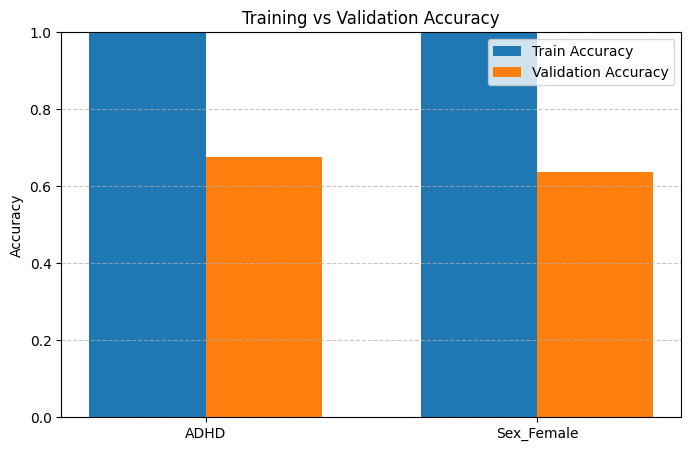

In [ ]:
train_acc_adhd = accuracy_score(y_train_adhd, y_train_pred_adhd)
val_acc_adhd = accuracy_score(y_val_adhd, y_val_pred_adhd)

train_acc_sex_f = accuracy_score(y_train_sex_f, y_train_pred_sex_f)
val_acc_sex_f = accuracy_score(y_val_sex_f, y_val_pred_sex_f)


print(f"Train Accuracy adhd: {train_acc_adhd:.4f}")
print(f"Validation Accuracy adhd: {val_acc_adhd:.4f}")

print(f"Train Accuracy sex_f: {train_acc_sex_f:.4f}")
print(f"Validation Accuracy sex_f: {val_acc_sex_f:.4f}")

# Prepare data
labels = ['ADHD', 'Sex_Female']
train_acc = [train_acc_adhd, train_acc_sex_f]
val_acc   = [val_acc_adhd, val_acc_sex_f]
x = np.arange(len(labels))  # the label locations
width = 0.35                 # width of the bars

# Plot
plt.figure(figsize=(8,5))
plt.bar(x - width/2, train_acc, width, label='Train Accuracy')
plt.bar(x + width/2, val_acc,   width, label='Validation Accuracy')
plt.ylim(0, 1)
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xticks(x, labels)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

In [ ]:
# Function to evaluate model performance
def evaluate_model(y_true, y_pred, model_name, feature_names=None, top_n=20):
    print(f"\n----- {model_name} Model Evaluation -----")
    print(f"Accuracy: {accuracy_score(y_true, y_pred):.4f}")
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))

    # Create confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Negative', 'Positive'],
                yticklabels=['Negative', 'Positive'])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'Confusion Matrix - {model_name}')
    plt.show()

    # Feature importance
    model = model_adhd if model_name == 'ADHD' else model_sex_f
    importance = model.feature_importances_

    # Create indices or use feature names if provided
    if feature_names is not None:
        features = feature_names
    else:
        features = [f"Feature {i}" for i in range(len(importance))]

    # Create DataFrame of feature importances
    feature_importance_df = pd.DataFrame({
        'Feature': features,
        'Importance': importance
    })
    # Sort by importance
    feature_importance_df = feature_importance_df.sort_values('Importance', ascending=False)

    # Plot top N features
    plt.figure(figsize=(12, 8))
    top_features = feature_importance_df.head(top_n)
    sns.barplot(x='Importance', y='Feature', data=top_features, palette='viridis')
    plt.title(f'Top {top_n} Feature Importance - {model_name}')
    plt.xlabel('Importance')
    plt.ylabel('Feature')
    plt.tight_layout()
    plt.show()


----- ADHD Model Evaluation -----
Accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       305
           1       1.00      1.00      1.00       665

    accuracy                           1.00       970
   macro avg       1.00      1.00      1.00       970
weighted avg       1.00      1.00      1.00       970



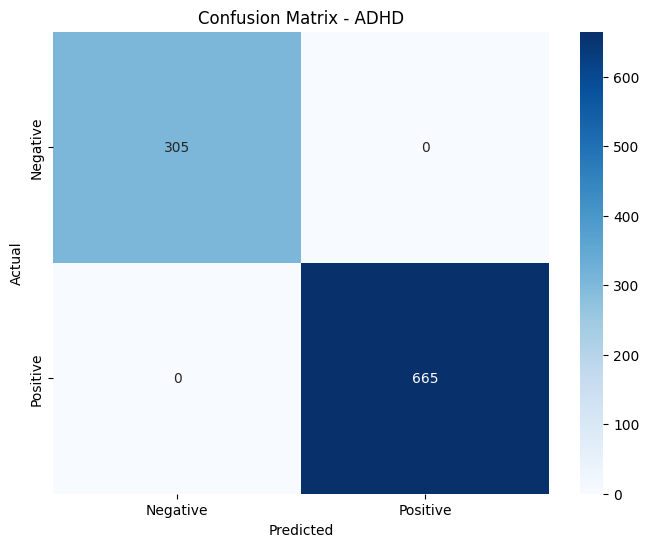

<ipython-input-43-d2170f6079b9>:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=top_features, palette='viridis')


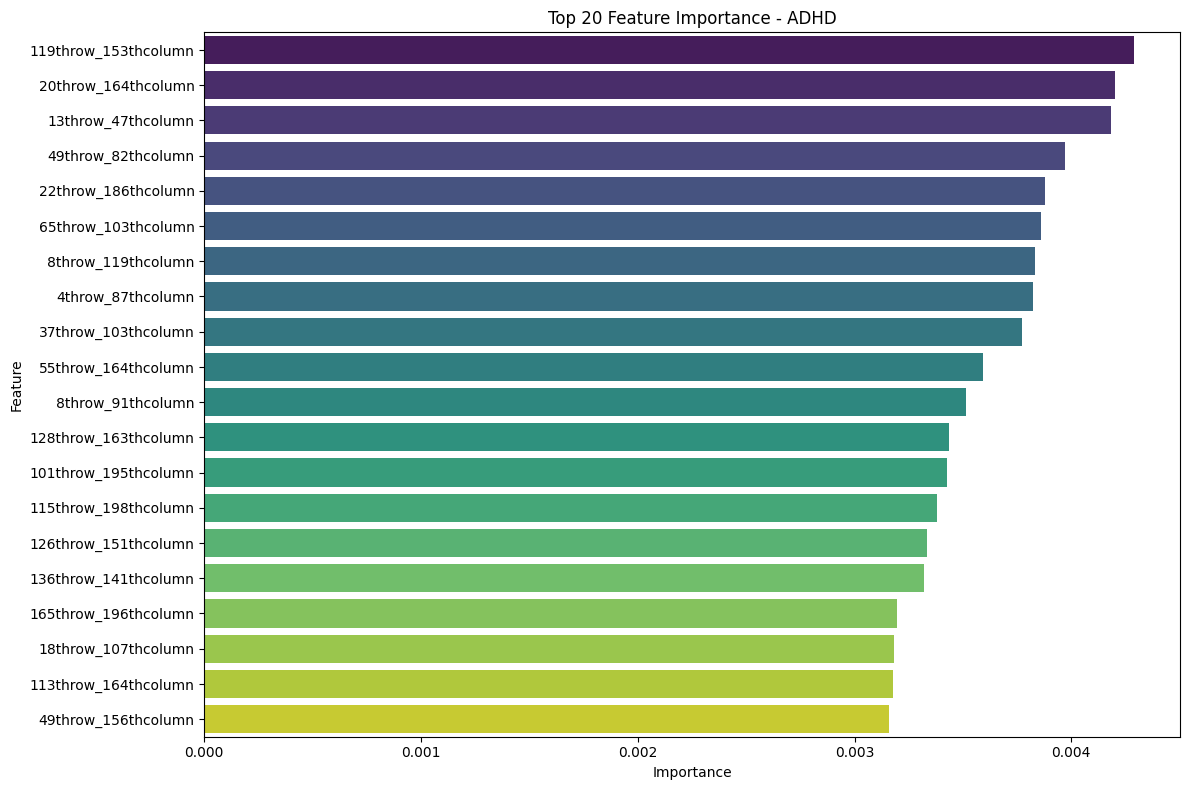

In [ ]:
evaluate_model(y_train_adhd, y_train_pred_adhd, 'ADHD', X_train_adhd.columns)


----- Sex_F Model Evaluation -----
Accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       637
           1       1.00      1.00      1.00       333

    accuracy                           1.00       970
   macro avg       1.00      1.00      1.00       970
weighted avg       1.00      1.00      1.00       970



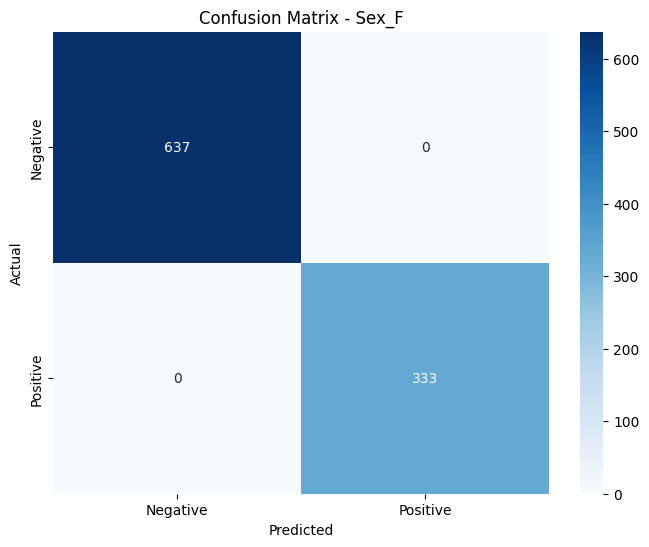

<ipython-input-43-d2170f6079b9>:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=top_features, palette='viridis')


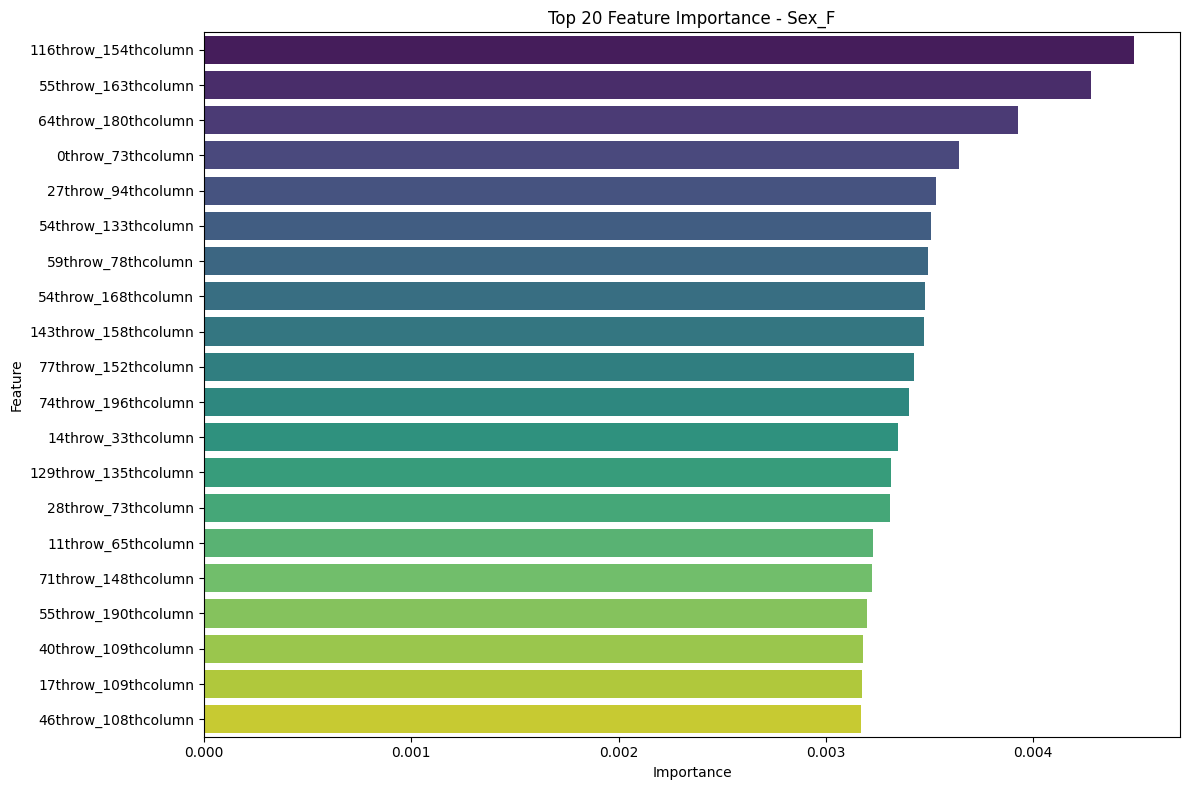

In [ ]:
evaluate_model(y_train_sex_f, y_train_pred_sex_f, 'Sex_F', X_train_sex_f.columns)